In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from itertools import combinations
import pandas as pd
import collections

##### Dados. Começa com 10 ativos simulados: sorteia um retorno médio mensal pra cada, gera uma série de uns 60 meses com ruído, e calcula a matriz de covariância. Assim você não depende de baixar nada. Trocar por dados reais depois é só mudar a origem da matriz.

##### Representação. O indivíduo é o vetor de pesos, tipo [0.15, 0.0, 0.32, ...], um por ativo.

##### Função objetivo. O índice de Sharpe da carteira: retorno esperado sobre o desvio-padrão. Maximização.#

In [2]:
ativos = [i for i in range(10)]
periodos = [i for i in range(60)]

In [3]:
# df = pd.DataFrame(np.random.normal(0.01,0.11,(60,10)), index = periodos, columns=ativos)
# print(df.describe())
# for i in range(len(df.columns)):
#     if random.random() <0.5:
#         df[i] = df[i]*random.random()**2
# print(df.describe())

df = pd.read_csv('df_ativos_2025.csv').set_index('date')
colunas = df.columns
df = df.rename(columns={colunas[i]:i for i in range(len(colunas))})
df = df[[0,4,10,20,24,30,40,50,60,70]]

In [4]:
# individuos = [0.03,0.05,0.2,0.4]
media_ativos = df.mean()
cov = df.cov()
def fo(lista):
    pesos = np.array(lista)
    mi_x = (pesos*media_ativos).sum()
    dv_carteira =  np.sqrt(pesos.T @ cov @ pesos)   
    sharpe = mi_x/dv_carteira

    return sharpe

In [59]:
listaf = [1, 44, 5, 3, 2, 5, 80, 0, 0, 0]
b = sorted(listaf, reverse=True)[:5]  # [80, 44, 5, 5, 3]

# Remove diretamente da listaf
for item in b:
    listaf.remove(item)
print(b)
print(listaf)
# Resultado: [1, 2, 0, 0, 0]

[80, 44, 5, 5, 3]
[1, 2, 0, 0, 0]


In [ ]:
def ga(pop_tamanho, num_gen):

    # inicialização
    pop = []
    fit_history= []
    solutions_history= []

    best_solution = None
    best_fit = float('-inf')

    # preencher pop
    for p in range(pop_tamanho):
        # p = list(np.random.dirichlet(np.ones(5),size=1)[0])+list(np.zeros(5))
        v = list(list(np.random.dirichlet(np.ones(5),size=1)[0])+list(np.zeros(5)))
        random.shuffle(v)
        pop.append(v)

    for ngen in range(num_gen):

        # evaluation
        fitness_pop = [fo(p) for p in pop]
        # seleção
        pais = []
        for i in range(pop_tamanho):

            p0 = random.sample(range(len(pop)), k=3)
            max0 = max(p0, key = lambda p: fitness_pop[p])
            pais.append(pop[max0])

        # crossover
        offspring = []
        tamanho_max = len(pais[0])
        for i in range(pop_tamanho):
            # n = random.randint(2,tamanho_max-2)
            pai1 = random.choice(pais)

            # preciso pegar os 5 maiores, zerar o resto, Ok
            #dentros os 5 amiores, pode ter zeros, preciso verificar isso e atribuir peso
            
            #pegar top5
            top5 = sorted(pai1, reverse=True)[:5]
            for item in top5:
                pai1.remove(item)

            # realizar o REPAIR nos top5
            sum_top5 = sum(top5)
            top5_repair = [top5[i]/sum_top5 for i in range(len(top5))]
            filho = top5_repair+list(np.zeros(5))
            print(filho)

            offspring.append(filho)
        
        # mutation
        tx = 1/8
        for i in range(len(offspring)):
            if random.random() < tx:
                j_value = random.randint(0,len(offspring[i])-1)
                troca =  abs(random.gauss(0, 0.05))
                if offspring[i][j_value] < troca: 
                    offspring[i][j_value] = abs(offspring[i][j_value] - troca)
                else:
                    offspring[i][j_value] = offspring[i][j_value] + troca
            soma = sum(offspring[i])
            offspring[i] = [offspring[i][j]/soma for j in range(len(offspring[i]))]

        # elitism
        if best_solution is not None:
            offspring[0] = best_solution

        pop = offspring

        if pop:
            best_solution = max(pop, key=lambda p: fo(p))
            best_fit = fo(best_solution)
        fit_history.append(best_fit)
        solutions_history.append(best_solution)

        print(f"Geração {ngen+1}, Best solution: {best_solution}, Best Fitness: {best_fit}")
    return solutions_history

In [67]:
sols = ga(700,200)

[np.float64(0.5791269885396945), np.float64(0.22375538687951704), np.float64(0.12326760279569067), np.float64(0.059496963038100044), np.float64(0.014353058746997764), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
[np.float64(0.562127399528062), np.float64(0.3475656814438945), np.float64(0.0463308122568043), np.float64(0.025806764019810826), np.float64(0.018169342751428317), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
[np.float64(0.3694461454598705), np.float64(0.2345033901823393), np.float64(0.1923777686883111), np.float64(0.13907880302820982), np.float64(0.06459389264126938), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
[np.float64(0.602816837095268), np.float64(0.25467698191948074), np.float64(0.11110189739090985), np.float64(0.029475254873086706), np.float64(0.0019290287212548134), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]

C:\Users\Pichau\AppData\Local\Temp\ipykernel_24516\2355938049.py:47: RuntimeWarning: invalid value encountered in scalar divide
  top5_repair = [top5[i]/sum_top5 for i in range(len(top5))]
C:\Users\Pichau\AppData\Local\Temp\ipykernel_24516\2355938049.py:64: RuntimeWarning: invalid value encountered in scalar divide
  offspring[i] = [offspring[i][j]/soma for j in range(len(offspring[i]))]


ValueError: operands could not be broadcast together with shapes (5,) (10,) 

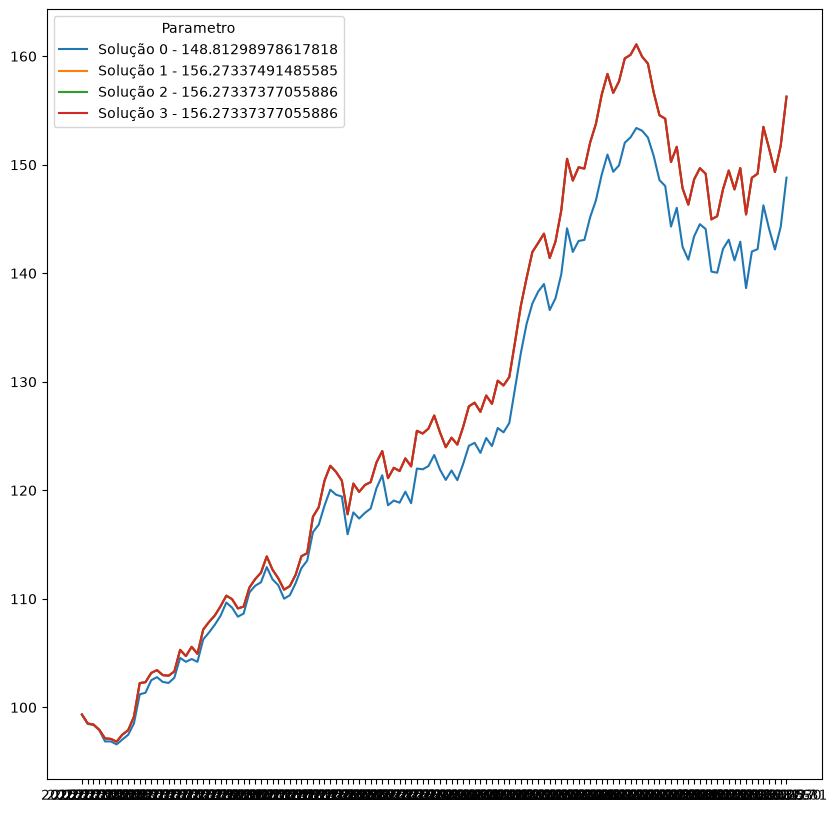

In [34]:
fig, ax = plt.subplots(figsize=(10,10))

for i, sol in enumerate([sols[0],sols[20],sols[100],sols[-1]]):
    carteira = df@sol
    acumulado = carteira+1
    ac = acumulado.cumprod()*100
    # Adicionado o parâmetro 'label' aqui:
    ax.plot(ac.index, ac.values, label=f"Solução {i} - {ac.values[-1]}")
ax.legend(title="Parametro")
plt.show()